# COMPLEX MODELS WEEK 7 TUTORIAL 2 SEKOU RUDDOCK

In [3]:
#IMPORT ALL NEEDED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

pd.set_option("display.width", 120)
print("Libraries loaded. Time to Cook!🍳")

Libraries loaded. Time to Cook!🍳


# LOAD AND CLEAN RAW DATA

In [4]:
import os


#Import RAW Dataset from google drive
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/ColabNotebooks/CARISURG_DATASETS/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Unable to find {DATA_PATH}.")

df_raw = pd.read_csv(DATA_PATH)
print("Loaded", df_raw.shape[0], "rows and", df_raw.shape[1], "columns from:", DATA_PATH)
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 rows and 226 columns from: /content/drive/MyDrive/ColabNotebooks/CARISURG_DATASETS/yaleemmlc_admissionprediction_triage.csv


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# CLEANING RAW DATA

In [5]:
#DATA CLEANING

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
df = df_raw.copy()

# drop any stray index column
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

#force the vitals to be NUMBERS; unparseable text  becomes NaN
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows where it is missing or out of range
df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# blank out physically impossible vitals
df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# encode gender to 0/1 (handles odd casings like "m" / "MALE")
df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

# fill remaining missing numbers  with the column median (simple and defensible)
for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


# CHOOSING FEATURES AND TARGET (X AND Y)

In [6]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]
print("Model will use", len(FEATURES), "features. First few:", FEATURES[:6])

Model will use 208 features. First few: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device']


In [7]:
# REPRODUCING WEEK 6 DATA SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 44096 | test: 11025


# SIZE UP CC_OTHER

In [8]:
# Sizes up the cc_other catch-all so you can judge it
if "cc_other" in df.columns:
    cc_cols = [c for c in df.columns if c.startswith("cc_")]
    total = len(df)
    has_other = int(df["cc_other"].sum())
    only_other = int(((df["cc_other"] == 1) & (df[cc_cols].sum(axis=1) == 1)).sum())
    print(f"Patients flagged cc_other: {has_other} of {total} ({has_other/total:.1%})")
    print(f"...and of those, patients whose ONLY complaint is 'other': {only_other}")
    print("\nMean ESI by cc_other flag (does 'other' lean urgent or not?):")
    print(df.groupby("cc_other")["esi"].mean().round(2))
else:
    print("No cc_other column in this sample — skipping. (On the full extract it will run.)")

Patients flagged cc_other: 4491 of 55121 (8.1%)
...and of those, patients whose ONLY complaint is 'other': 3352

Mean ESI by cc_other flag (does 'other' lean urgent or not?):
cc_other
0.0    2.87
1.0    3.01
2.0    3.26
3.0    3.00
Name: esi, dtype: float64


# WEEK 6 BASELINE REVIEW

In [11]:
#REBUILD WEEK 6 BASELINE

baseline = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=42))
baseline.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, baseline.predict(X_test), average="macro")
print("Baseline (logistic regression) macro-F1:", round(baseline_f1, 3))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Baseline (logistic regression) macro-F1: 0.492


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# FEATURE ENGINEERING

In [9]:
#Builds new clinical features from existing vitals,

def add_clinical_features(data):
    out = data.copy()

    # atios & combinations
    out["shock_index"]    = out["triage_vital_hr"] / out["triage_vital_sbp"]       # HR / SBP         (uses BP)
    out["pulse_pressure"] = out["triage_vital_sbp"] - out["triage_vital_dbp"]      # SBP - DBP        (uses BP)
    out["spo2_rr_ratio"]  = out["triage_vital_o2"] / out["triage_vital_rr"]        # oxygen vs effort (NO BP)

    # red-flag flags that do NOT use blood pressure:
    out["is_tachypneic"] = (out["triage_vital_rr"]   > 20   ).astype(int)   # fast breathing
    out["is_hypoxic"]    = (out["triage_vital_o2"]   < 92   ).astype(int)   # low oxygen
    out["is_febrile"]    = (out["triage_vital_temp"] >= 100.4).astype(int)  # fever
    #More features
    out["is_bradycardic"] = (out["triage_vital_hr"] < 60).astype(int) # a dangerously slow heart rate
    out["is_hyperglycaemic"] = (out["triage_glucose"] > 180).astype(int) # poorly controlled or physiologically stressed
    out["resp_distress"] = ((out["is_hypoxic"] == 1) | (out["is_tachypneic"] == 1)).astype(int) # a combined respiratory red flag

    # TODO (stretch) — a severity score = how many red flags fire:
    red_flag_cols = ["is_tachypneic", "is_hypoxic", "is_febrile", "is_bradycardic", "is_hyperglycaemic", "resp_distress"]
    out["red_flag_count"] = out[red_flag_cols].sum(axis=1)

    return out

X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)
print("Features after engineering:", X_train_fe.shape[1])
X_train_fe.head()

Features after engineering: 218


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,shock_index,pulse_pressure,spo2_rr_ratio,is_tachypneic,is_hypoxic,is_febrile,is_bradycardic,is_hyperglycaemic,resp_distress,red_flag_count
35369,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0.866667,49.0,4.454545,1,0,0,0,0,1,2
52043,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0.678261,39.0,5.333333,0,0,0,0,0,0,0
13610,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0.806723,41.0,5.222222,0,0,0,0,0,0,0
54796,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0.695312,35.0,6.125000,0,0,0,0,0,0,0
11096,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0.787611,35.0,5.444444,0,0,0,0,0,0,0


# RANDOM FORREST MODEL

In [13]:
# Trains a random forest and shows which features it leaned on.

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            random_state=42, n_jobs=-1)
rf.fit(X_train_fe, y_train)

rf_f1 = f1_score(y_test, rf.predict(X_test_fe), average="macro")
print("Random Forest macro-F1:", round(rf_f1, 3))

print("\nFeature Importances:")
print(pd.Series(rf.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False).head(10))

Random Forest macro-F1: 0.384

Feature Importances:
shock_index          0.075656
triage_vital_sbp     0.074657
triage_vital_dbp     0.071413
triage_glucose       0.067910
pulse_pressure       0.066907
triage_vital_hr      0.065869
triage_vital_temp    0.061023
spo2_rr_ratio        0.049084
cc_strokealert       0.036903
triage_vital_o2      0.036688
dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Encoding categorical features so the model can understand ethnicity, age and gender

demo_1hot = pd.get_dummies(df[["ethnicity", "race"]], prefix=["eth", "race"], dtype=int)
print("New one-hot columns:", list(demo_1hot.columns))

def add_demographics(X_fe):
    """Bolt the encoded demographics onto an existing feature frame (aligned by row)."""
    rows = X_fe.index
    extra = demo_1hot.loc[rows].copy()
    extra["age"] = df.loc[rows, "age"]         # numeric already
    extra["gender"] = df.loc[rows, "gender"]   # 0/1 already
    return pd.concat([X_fe, extra], axis=1)

X_train_plus = add_demographics(X_train_fe)
X_test_plus = add_demographics(X_test_fe)
print("Features WITHOUT demographics:", X_train_fe.shape[1])
print("Features WITH    demographics:", X_train_plus.shape[1])
X_train_plus.filter(like="race_").head()

New one-hot columns: ['eth_Hispanic or Latino', 'eth_Non-Hispanic', 'eth_Patient Refused', 'eth_Unknown', 'race_American Indian or Alaska Native', 'race_Asian', 'race_Black or African American', 'race_Native Hawaiian or Other Pacific Islander', 'race_Other', 'race_Patient Refused', 'race_Unknown', 'race_White or Caucasian']
Features WITHOUT demographics: 218
Features WITH    demographics: 232


,race_American Indian or Alaska Native,race_Asian,race_Black or African American,race_Native Hawaiian or Other Pacific Islander,race_Other,race_Patient Refused,race_Unknown,race_White or Caucasian
35369,0,0,0,0,1,0,0,0
52043,0,0,0,0,0,0,0,1
13610,0,0,0,0,0,0,0,1
54796,0,0,1,0,0,0,0,0
11096,0,0,0,0,0,0,0,1


# RANDOM FOREST CLASSIFIER TRAINING

In [ ]:
# retrains the forest with the encoded demographics

rf_demo = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
rf_demo.fit(X_train_plus, y_train)
rf_demo_f1 = f1_score(y_test, rf_demo.predict(X_test_plus), average="macro")

print("Demographics-free Random Forest macro-F1:", round(rf_f1, 3))
print("Random Forest WITH demographics macro-F1:", round(rf_demo_f1, 3))

Demographics-free Random Forest macro-F1: 0.384
Random Forest WITH demographics macro-F1: 0.388


In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: searches random-forest settings with 3-fold CV and
# keeps the combination that scores best on macro-F1.
# ------------------------------------------------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="f1_macro",
    random_state=42, # Ensure reproducibility of the random search
    n_jobs=-1
)

search.fit(X_train_fe, y_train)

print("Best parameters:", search.best_params_)
print("Best cross-validation macro-F1:", round(search.best_score_, 3))

# Score the best estimator on the test set
best_rf = search.best_estimator_
optimized_rf_f1 = f1_score(y_test, best_rf.predict(X_test_fe), average="macro")
print("Test set macro-F1 with optimized RF:", round(optimized_rf_f1, 3))

Best parameters: {'n_estimators': 200, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None}
Best cross-validation macro-F1: 0.462
Test set macro-F1 with optimized RF: 0.476


In [ ]:
#SAVE RF MODEL
from pathlib import Path
model_save_path = Path("/content/drive/MyDrive/ColabNotebooks") / "w7_random_forest.joblib"
joblib.dump(best_rf, model_save_path)

['/content/drive/MyDrive/ColabNotebooks/w7_random_forest.joblib']

# Gradient Boosting Model

In [12]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: trains a gradient-boosting model. No scaling needed.
# ------------------------------------------------------------------
hgb = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.1, max_iter=300,
    class_weight="balanced", random_state=42)
hgb.fit(X_train_fe, y_train)
hgb_f1 = f1_score(y_test, hgb.predict(X_test_fe), average="macro")
print("Gradient Boosting macro-F1:", round(hgb_f1, 3))

Gradient Boosting macro-F1: 0.417


# MLP Small Neural Network

In [15]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: trains a small neural network on SCALED features.
# ------------------------------------------------------------------
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=500, random_state=42))
mlp.fit(X_train_fe, y_train)
mlp_f1 = f1_score(y_test, mlp.predict(X_test_fe), average="macro")
print("Small MLP macro-F1:", round(mlp_f1, 3))

Small MLP macro-F1: 0.501


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


# SCORE BENCHMARK TABLE

In [15]:
#LOAD SAVED MODELS
best_rf = joblib.load("/content/drive/MyDrive/ColabNotebooks/w7_random_forest.joblib")
hgb = joblib.load("/content/drive/MyDrive/ColabNotebooks/w7_gradient_boosting.joblib")
mlp = joblib.load("/content/drive/MyDrive/ColabNotebooks/w7_mlp.joblib")

In [17]:
from sklearn.metrics import f1_score, recall_score
import pandas as pd

def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

# Generate predictions for each model
baseline_preds = baseline.predict(X_test)
rf_preds = rf.predict(X_test_fe)
best_rf_preds = best_rf.predict(X_test_fe)
hgb_preds = hgb.predict(X_test_fe)
mlp_preds = mlp.predict(X_test_fe)

table = pd.DataFrame([
    summarise("Baseline", baseline_preds),
    summarise("Random Forest", rf_preds),
    summarise("Random Forest (tuned)", best_rf_preds),
    summarise("Gradient Boosting", hgb_preds),
    summarise("Small MLP", mlp_preds),
])
table

NameError: name 'best_rf' is not defined

# Saving MLP and Gradient Boosting Model

In [14]:
model_save_path2 = Path("/content/drive/MyDrive/ColabNotebooks") / "w7_gradient_boosting.joblib"
joblib.dump(hgb, model_save_path2)
model_save_path3 = Path("/content/drive/MyDrive/ColabNotebooks") / "w7_mlp.joblib"
joblib.dump(mlp, model_save_path3)
print("Saved: w7_gradient_boosting.joblib, w7_mlp.joblib ✅")


Saved: w7_gradient_boosting.joblib, w7_mlp.joblib ✅


# SIX AXES AND MORE

In [18]:
import time
import pandas as pd
from sklearn.metrics import f1_score, recall_score

def summarise(name, model, X_train_data, y_train_data, X_test_data):
    # Time training
    t0 = time.perf_counter()
    model.fit(X_train_data, y_train_data) # training
    train_time = time.perf_counter() - t0

    # Time inference
    t0 = time.perf_counter()
    preds = model.predict(X_test_data)
    infer_ms = (time.perf_counter() - t0) / len(X_test_data) * 1000 # per prediction

    return {
        "model": name,
        "accuracy": round((preds == y_test).mean(), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
        "train_time_s": round(train_time, 3),
        "infer_ms_per_sample": round(infer_ms, 3)
    }

table = pd.DataFrame([
    summarise("Baseline", baseline, X_train, y_train, X_test),
    summarise("RF", rf, X_train_fe, y_train, X_test_fe),
    summarise("RF (tuned)", best_rf, X_train_fe, y_train, X_test_fe),
    summarise("HGB", hgb, X_train_fe, y_train, X_test_fe),
    summarise("MLP", mlp, X_train_fe, y_train, X_test_fe)
])
table

,model,accuracy,macro_F1,recall_ESI1,train_time_s,infer_ms_per_sample
0,Baseline,0.667,0.492,0.250,19.980,0.003
1,RF,0.638,0.384,0.000,62.574,0.137
2,RF (tuned),0.610,0.476,0.312,381.502,0.105
3,HGB,0.550,0.417,0.312,12.054,0.022
4,MLP,0.634,0.471,0.188,281.323,0.005


# CONFUSION MATRIX AND HISTOGRAM

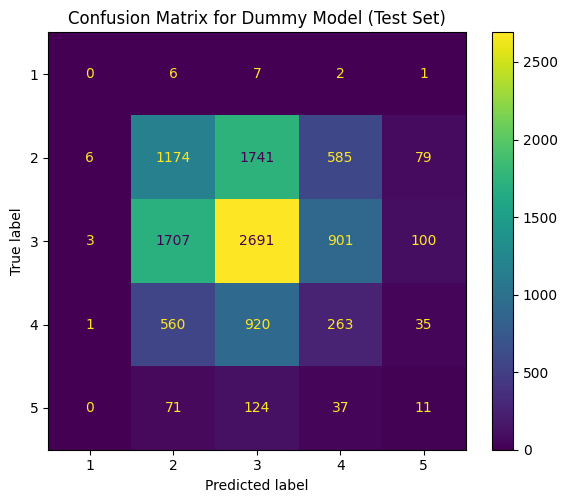

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


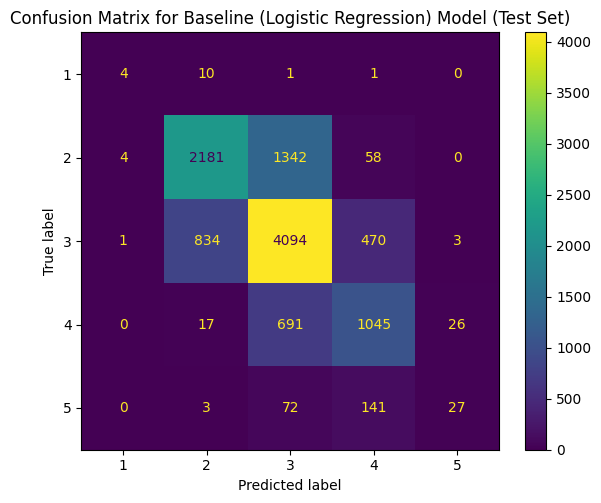

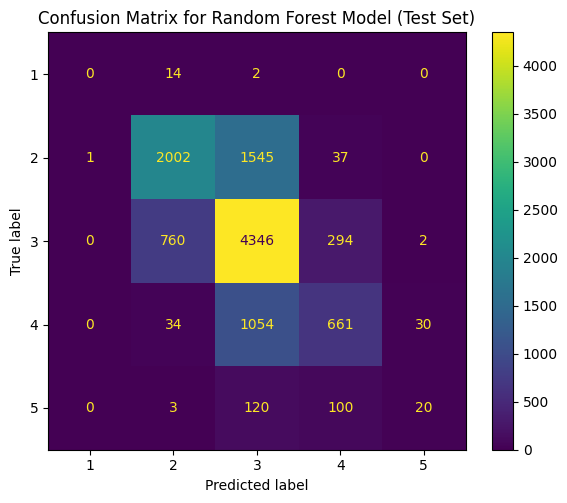

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


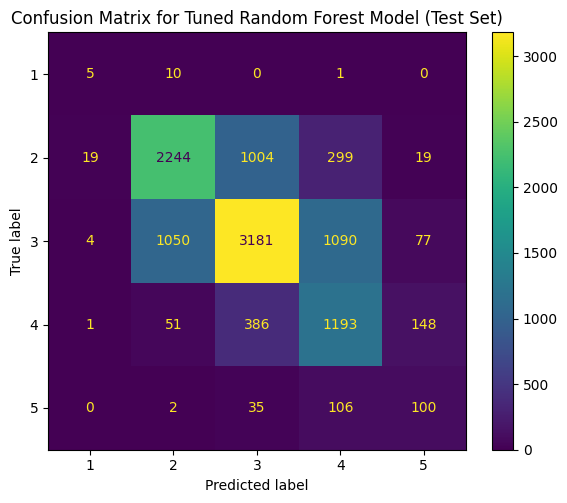

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


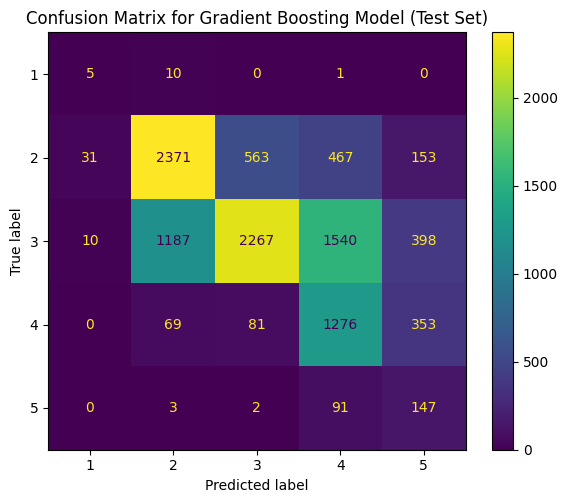

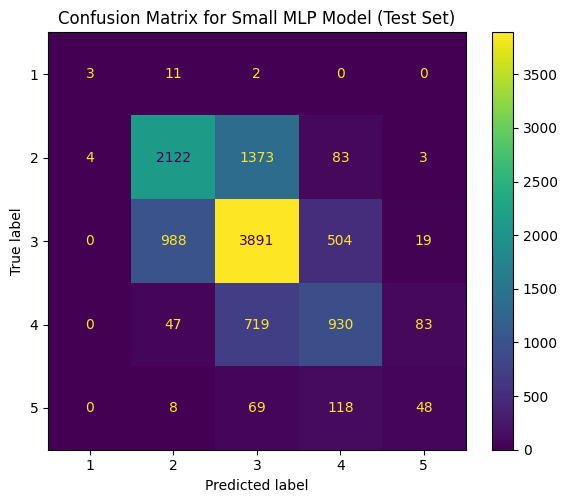

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix for Dummy Model (retained from original request)
dummy = DummyClassifier(strategy="stratified", random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, dummy.predict(X_test), ax=ax)
ax.set_title("Confusion Matrix for Dummy Model (Test Set)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Baseline (Logistic Regression) Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, baseline.predict(X_test), ax=ax)
ax.set_title("Confusion Matrix for Baseline (Logistic Regression) Model (Test Set)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Random Forest Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf.predict(X_test_fe), ax=ax)
ax.set_title("Confusion Matrix for Random Forest Model (Test Set)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Tuned Random Forest Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_rf.predict(X_test_fe), ax=ax)
ax.set_title("Confusion Matrix for Tuned Random Forest Model (Test Set)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Gradient Boosting Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, hgb.predict(X_test_fe), ax=ax)
ax.set_title("Confusion Matrix for Gradient Boosting Model (Test Set)")
plt.tight_layout()
plt.show()

# Confusion Matrix for Small MLP Model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, mlp.predict(X_test_fe), ax=ax)
ax.set_title("Confusion Matrix for Small MLP Model (Test Set)")
plt.tight_layout()
plt.show()

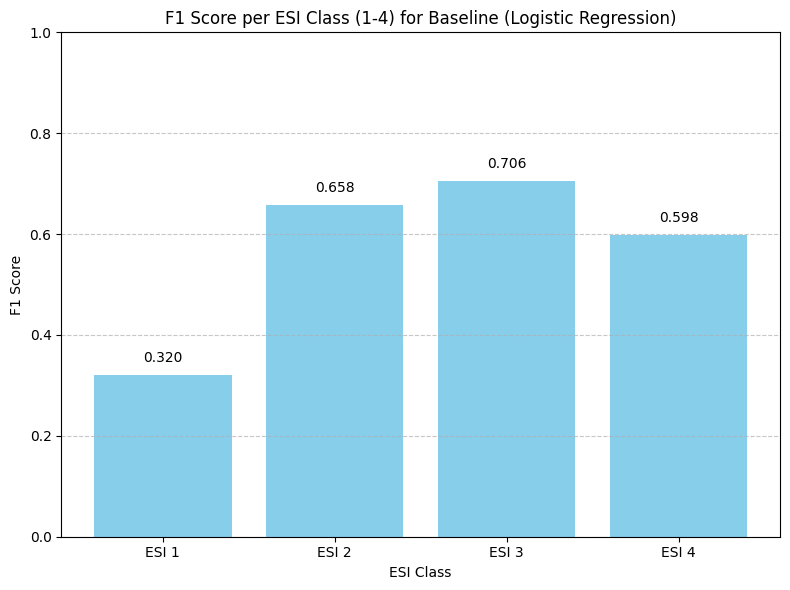

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


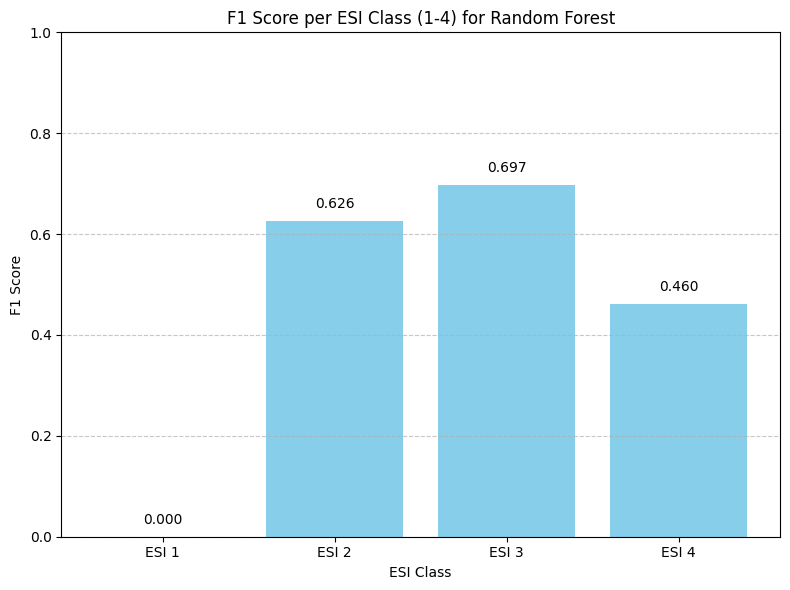

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


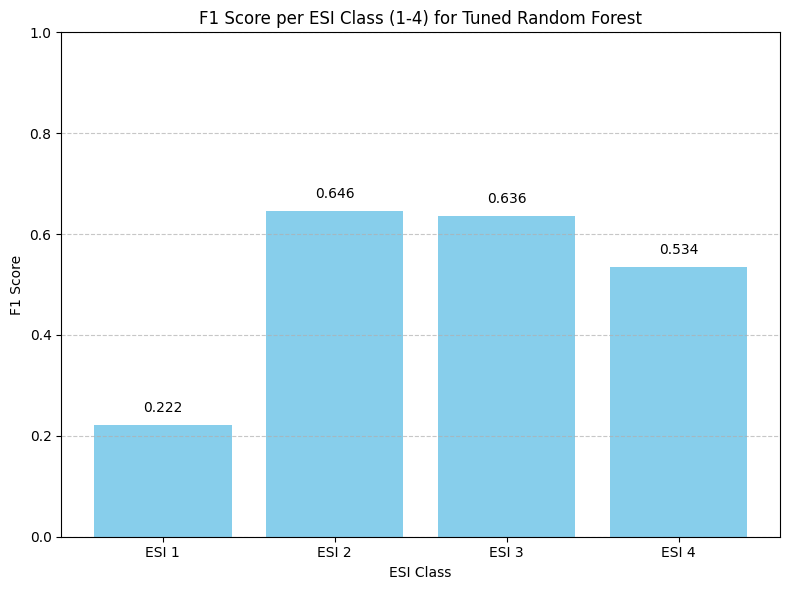

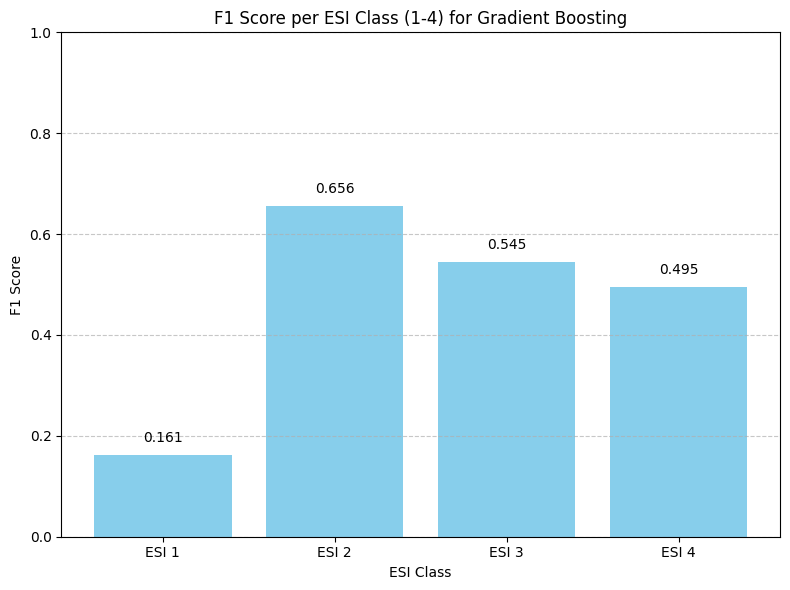

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


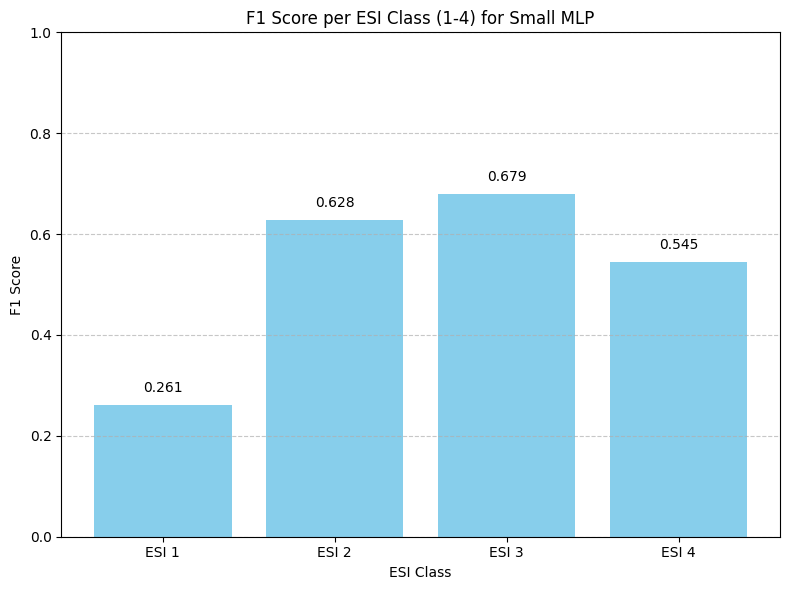

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

def plot_f1_histogram(model_name, y_true, y_pred):
    # Get all unique ESI classes from the test set
    esi_classes_all = sorted(y_true.unique())
    # Calculate F1 scores for each class
    f1_scores_per_class_all = f1_score(y_true, y_pred, labels=esi_classes_all, average=None)

    # Filter for ESI classes 1 through 4 as requested
    plot_labels = [f"ESI {c}" for c in esi_classes_all if c >= 1 and c <= 4]
    plot_scores = [score for i, score in enumerate(f1_scores_per_class_all) if esi_classes_all[i] >= 1 and esi_classes_all[i] <= 4]

    fig, ax = plt.subplots(figsize=(8, 6)) # Adjust figure size for better readability
    ax.bar(plot_labels, plot_scores, color='skyblue') # Use a consistent color
    ax.set_ylabel('F1 Score')
    ax.set_xlabel('ESI Class') # Add x-axis label
    ax.set_title(f'F1 Score per ESI Class (1-4) for {model_name}')
    ax.set_ylim(0, 1) # F1 scores are between 0 and 1

    for i, score in enumerate(plot_scores):
        ax.text(i, score + 0.02, f'{score:.3f}', ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
    plt.tight_layout()
    plt.show()

# Generate predictions for each model
baseline_preds = baseline.predict(X_test)
rf_preds = rf.predict(X_test_fe)
best_rf_preds = best_rf.predict(X_test_fe)
hgb_preds = hgb.predict(X_test_fe)
mlp_preds = mlp.predict(X_test_fe)

# Plot F1 score histograms for each model
plot_f1_histogram("Baseline (Logistic Regression)", y_test, baseline_preds)
plot_f1_histogram("Random Forest", y_test, rf_preds)
plot_f1_histogram("Tuned Random Forest", y_test, best_rf_preds)
plot_f1_histogram("Gradient Boosting", y_test, hgb_preds)
plot_f1_histogram("Small MLP", y_test, mlp_preds)